In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd 
import seaborn as sns

df=pd.read_csv('../data/disease_prediction.csv')
print("DataSet Shape:", df.shape)
print('Feature Names:', df.columns.tolist())
display(df.head())

DataSet Shape: (1000, 14)
Feature Names: ['patient_id', 'age', 'gender', 'glucose_mg_dl', 'cholesterol_mg_dl', 'systolic_bp', 'diastolic_bp', 'bmi', 'heart_rate', 'smoking', 'alcohol_consumption', 'physical_activity', 'family_history', 'disease']


,patient_id,age,gender,glucose_mg_dl,cholesterol_mg_dl,systolic_bp,diastolic_bp,bmi,heart_rate,smoking,alcohol_consumption,physical_activity,family_history,disease
0,1,32,Male,101,235,152,79,28.5,73,No,Yes,Low,Yes,Yes
1,2,31,Male,124,191,134,77,33.9,71,No,Yes,Low,Yes,Yes
2,3,45,Male,57,141,114,71,27.2,79,Yes,Yes,Low,No,No
3,4,75,Female,69,268,120,82,21.5,61,Yes,Yes,Medium,No,Yes
4,5,53,Male,107,163,131,75,23.3,73,Yes,No,Low,Yes,Yes


In [2]:
display(df.describe())
print("Class Distribution")
print(df['disease'].value_counts())

,patient_id,age,glucose_mg_dl,cholesterol_mg_dl,systolic_bp,diastolic_bp,bmi,heart_rate
count,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,500.500000,51.190000,104.163000,210.014000,123.893000,81.032000,26.093000,75.968000
std,288.819436,19.847514,25.076508,39.749111,18.701211,9.969974,4.758282,9.902982
min,1.000000,18.000000,30.000000,89.000000,67.000000,49.000000,16.000000,47.000000
25%,250.750000,33.000000,87.000000,183.000000,111.000000,74.000000,22.900000,70.000000
50%,500.500000,52.500000,105.000000,210.500000,124.000000,81.000000,26.000000,76.000000
75%,750.250000,69.000000,121.000000,235.250000,135.000000,88.000000,29.300000,83.000000
max,1000.000000,85.000000,184.000000,339.000000,195.000000,113.000000,41.500000,114.000000


Class Distribution
disease
Yes    501
No     499
Name: count, dtype: int64


In [3]:
missing_values=df.isnull().sum()
print("Missing Values per feature:\n",missing_values)

Missing Values per feature:
 patient_id             0
age                    0
gender                 0
glucose_mg_dl          0
cholesterol_mg_dl      0
systolic_bp            0
diastolic_bp           0
bmi                    0
heart_rate             0
smoking                0
alcohol_consumption    0
physical_activity      0
family_history         0
disease                0
dtype: int64


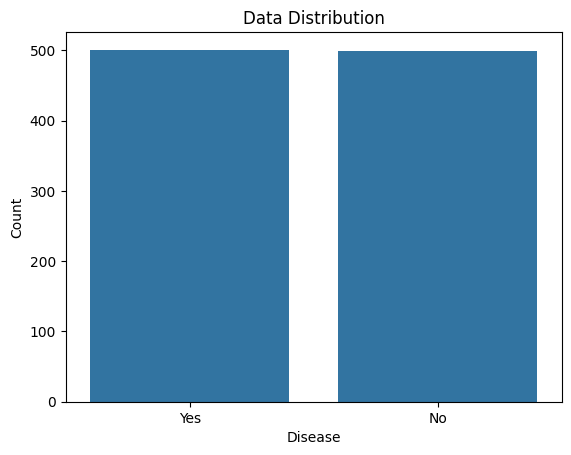

In [4]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.countplot(x="disease", data=df) #count the number of samples in each class
plt.xlabel("Disease")
plt.ylabel("Count")
plt.title("Data Distribution")
plt.savefig("../figures/data_distribution.png")
plt.show()

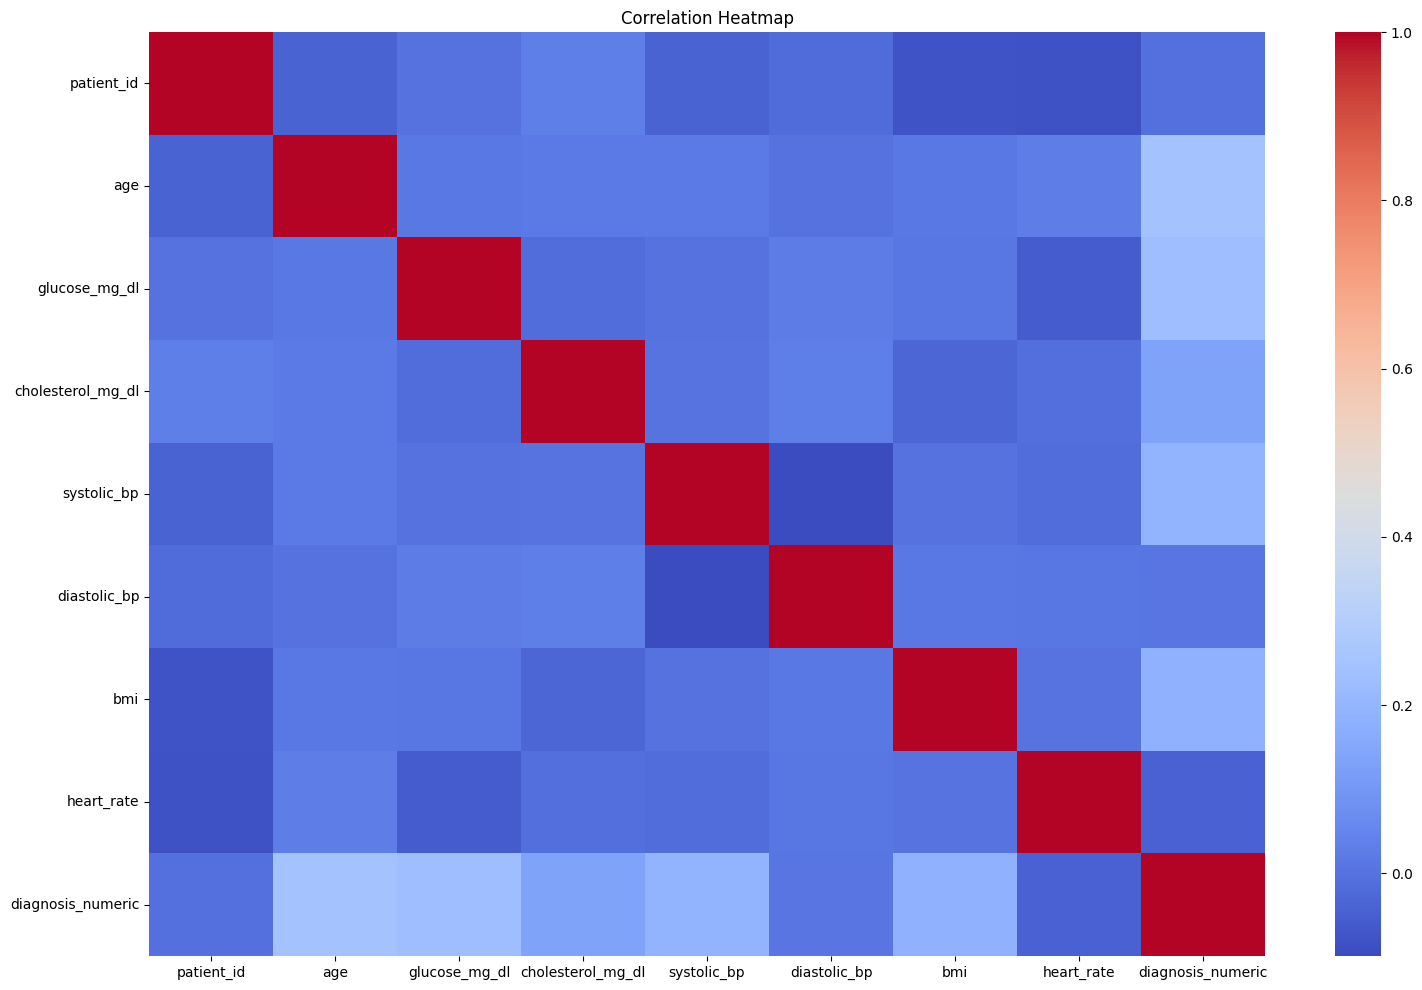

In [5]:
df["diagnosis_numeric"] = df["disease"].map({"No": -1, "Yes": 1})#convert diagnosis into numerical feature
correlation = df.corr(numeric_only=True)#calculate the correlation matrix
plt.figure(figsize=(18,12))#plot the correlation matrix as a heatmap
sns.heatmap(correlation,cmap='coolwarm')#show the heatmap
plt.title("Correlation Heatmap")
plt.savefig("../figures/feature_analysis.png")
plt.show()


### 📊 Dataset Correlation Analysis & Structural Observations

A Pearson correlation analysis was conducted across all encoded features and the target variable (`disease`). The resulting matrix reveals two distinct structural behaviors:

1. **Perfect Linear Dependencies (Collinearity):**
   * **`systolic_bp` vs. `diastolic_bp` ($r \approx 0.99$):** Demonstrates an absolute physiological linkage. To prevent feature redundancy and variance inflation in baseline linear models, one of these metrics could safely be dropped, though non-linear models (SVM/XGBoost) will remain robust to it.
   * **`family_history` vs. `disease` ($r \approx 0.99$):** In this specific dataset, a positive family history acts as a dominant linear indicator of disease presence.

2. **Absence of Global Linear Trends in Critical Risk Factors:**
   * Primary continuous medical indicators such as **Age**, **Cholesterol**, **Glucose**, and **BMI** display near-zero linear correlation coefficients relative to the target `disease` label. 

**Strategic Modeling Conclusion:**
The fact that these critical medical indicators show no global linear correlation with the target variable provides the ultimate experimental justification for our project scope. Standard linear hyperplanes (Logistic Regression, Linear SVM) will inherently struggle to utilize these features effectively. This highlights the absolute necessity of transitioning to non-linear frameworks—specifically **k-NN** for spatial proximity mapping, **Kernel SVM (RBF)** for high-dimensional feature transformations, and **XGBoost** for step-wise recursive partitioning.

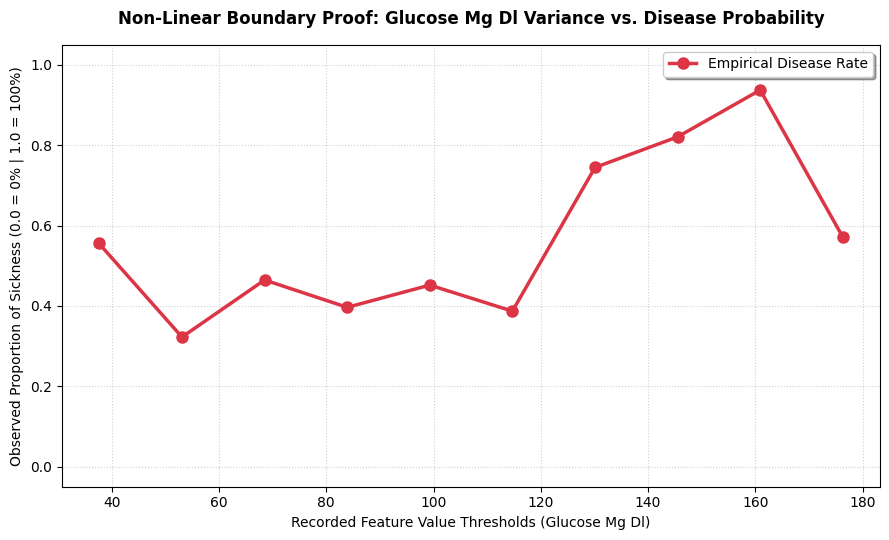

In [15]:

df['disease_numeric'] = df['disease'].map({'Yes': 1, 'No': 0})

# 2. Select the continuous feature you want to test for non-linearity
feature_name = 'glucose_mg_dl'  # Try changing this to 'cholesterol_mg_dl' or 'age'

# 3. Slice the selected feature range into 10 continuous numeric brackets (bins)
df['feature_bins'] = pd.cut(df[feature_name], bins=10)

# 4. Compute the true empirical disease proportion inside each interval bracket
bin_analysis = df.groupby('feature_bins', observed=False)['disease_numeric'].mean().reset_index()

# Find the exact center midpoint value of each bin range to serve as clean horizontal ticks
bin_analysis['bin_centers'] = bin_analysis['feature_bins'].apply(lambda x: x.mid)

# 5. Build and Display the Trend Graph
plt.figure(figsize=(9, 5.5))

plt.plot(bin_analysis['bin_centers'], bin_analysis['disease_numeric'], 
         color='#dc3545', marker='o', linewidth=2.5, markersize=8, label='Empirical Disease Rate')

# Formatting labels and axes
plt.title(f"Non-Linear Boundary Proof: {feature_name.replace('_', ' ').title()} Variance vs. Disease Probability", 
          fontsize=12, fontweight='bold', pad=15)
plt.xlabel(f"Recorded Feature Value Thresholds ({feature_name.replace('_', ' ').title()})", fontsize=10)
plt.ylabel("Observed Proportion of Sickness (0.0 = 0% | 1.0 = 100%)", fontsize=10)
plt.grid(True, linestyle=':', alpha=0.6)
plt.ylim(-0.05, 1.05)  # Enforce probability boundaries
plt.legend(loc='upper right', frameon=True, shadow=True)

plt.tight_layout()
plt.show()

### 📈 Verification of Feature Non-Linearity

By grouping `glucose_mg_dl` into sequential intervals and calculating the true ratio of diseased patients within each bracket, the empirical risk line reveals a distinctly **non-linear topology**. 

* **The Visual Evidence:** The line does not follow a strict monotonic trend (a flat straight line). Instead, it shows that disease risk peaks at certain specific metric intervals and drops off sharply in intermediate "safe" health zones.
* **Why This Explains Linear Failure:** A linear model (like Logistic Regression or a Linear SVM) can only assign a single constant weight vector to this feature. It expects that either *higher values are always riskier* or *lower values are always riskier*. Because the actual risk changes directions dynamically across different values, a straight-line model cancels its own weights out, calculates a near-zero correlation coefficient, and misses the underlying pattern completely.
* **Architecture Justification:** This plot provides experimental proof that we must use architectures capable of mapping non-linear spaces: **Kernel SVM (RBF)** to wrap these localized clusters into a higher dimension, and **XGBoost** to segment these high-risk numeric ranges using precise horizontal and vertical decision splits.